# Modeling a Desiccant Dryer

A typical rotating drum desiccant dryer consists of air channels coated with desiccant material. The drum rotates through different air streams to dry a process stream and then be regenerated.

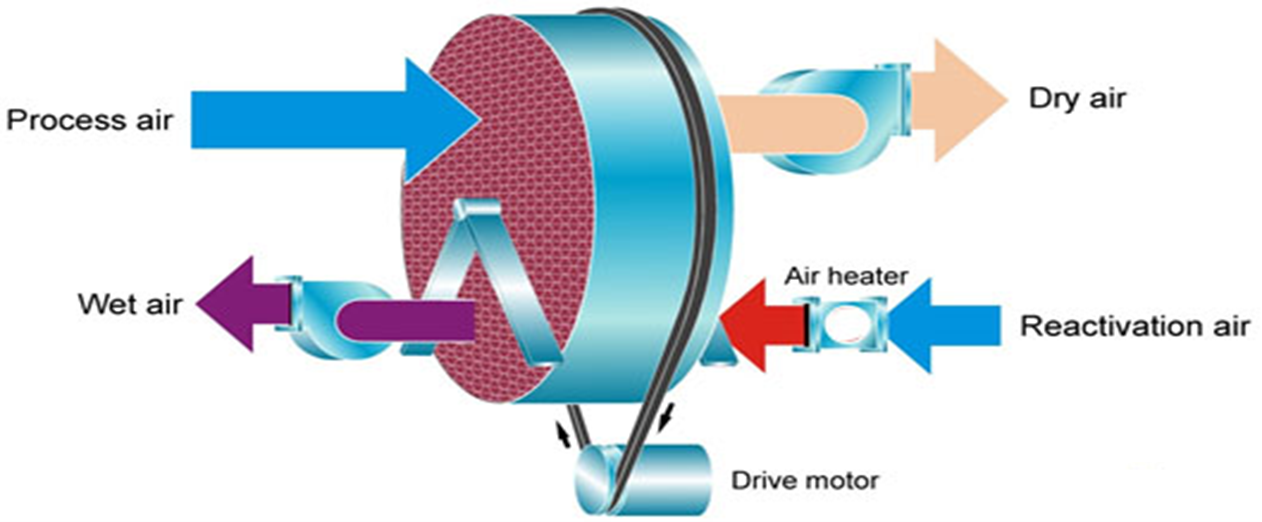

*:align: center*

The flow of a (humid) gas and the simultaneous adsorption of water through a channel can be described by transport equations for mass and heat. This process can be modeled using a homogeneous approach, where mass and heat transfer resistances between the gas and adsorbent are neglected. In this case, there is one PDE for humidity in both phases and one PDE for temperature:

$$
\begin{align*}
\frac{\partial}{\partial t} \left( \varepsilon \rho_{g} w_{g} + (1 - \varepsilon) f_{ds} \rho_{s} W_{ds} \right) + \frac{\partial}{\partial x} \left( v \rho_{g} w_{g} \right) &= 0, \\
\frac{\partial}{\partial t} \left( \left[ \varepsilon \rho_{g} C_{p,g} + (1 - \varepsilon) \rho_{s} C_{p,s} \right] T - (1 - \varepsilon) f_{ds} \rho_{s} W_{ds} H_{sor} \right) + \frac{\partial}{\partial x} \left( v \rho_{g} C_{p,g} T \right) &= 0.
\end{align*}
$$

In these equations, $w_{g}$ is the weight fraction of water in the air stream, and $W_{ds}$ is the weight of adsorbed water per kilogram of desiccant (a fraction $f_{ds}$ is used because there is also some inert solid material). The first equation expresses a mass balance where the accumulation of water in both the air and desiccant is balanced by the transport of water by the air stream. The superficial gas velocity is $v = 1.5~\mathrm{m~s^{-1}}$, and the length of a channel is $L = 0.2~\mathrm{m}$.

In the enthalpy balance, the accumulation term has two contributions: one due to heat capacity and another due to the (lower) enthalpy of adsorbed water. Here, $H_{sor}$ is the enthalpy of sorption, which causes heat to be generated when water is adsorbed. Enthalpy is transported along the channel by the gas flow.

The material properties are:

| Material    | Densities ($\mathrm{kg~m^{-3}}$) | Heat Capacities ($\mathrm{J~kg^{-1}~K^{-1}}$) | Volume Fractions |
|-------------|-----------------------------------|-----------------------------------------------|------------------|
| Air         | $\rho_{g} = 1.2$                 | $C_{p,g} = 1872$                              | $\varepsilon = 0.8$ |
| Adsorbent   | $\rho_{s} = 930$                 | $C_{p,s} = 1340$                              | $f_{ds} = 0.8$      |

Locally, the water in the air stream is assumed to be in equilibrium with the adsorbed amount of gas. The amount of adsorbed water is related to the relative humidity $\phi_{w}$ and is described by the following adsorption isotherm:

$$
W_{ds} = 0.30 \phi_{w}^{0.75},
$$

where:

$$
\phi_{w} = \frac{p}{p_{sat}} \frac{w_{g}}{0.64 + 0.36 w_{g}}, \quad p_{sat} = \exp\left( 23.20 - \frac{3816}{T - 46.13} \right).
$$

Here, $p_{sat}$ is the saturation pressure of water at temperature $T$, and $p$ is the total pressure in the channel. In this case, $p = 1~\mathrm{bar}$. The heat of sorption per kilogram of desiccant is:

$$
H_{sor}~\mathrm{[kJ~kg^{-1}]} =
\begin{cases}
2850 - 13.4 \cdot 10^{3} (W - 0.05), & W \leq 0.05, \\
2850 - 1.40 \cdot 10^{3} (W - 0.05), & W > 0.05.
\end{cases}
$$

**Questions**:

1. Implement the model for the water weight fraction in air, $w_{g}$, and temperature, $T$, as functions of position $x$ and time $t$. Suggested approach:
   - Use a coupled formulation where you solve $w_{g}$ and $T$ simultaneously as components 0 and 1 of a NumPy array.
   - Evaluate the convection term explicitly using first-order upwind (which can later be extended to, e.g., min-mod).
   - Treat the non-linear accumulation term using Newton-Raphson (using `newton` from the `pymrm` package). Compute the Jacobian of the accumulation term numerically (using `numjac`).

2. Model the adsorption of a humid stream with $w_{g,\mathrm{in}} = 0.015$ and $T_{\mathrm{in}} = 307.7~\mathrm{K}$.

3. **Advanced (optional)**: Simulate up to a cyclic stationary state of drying and regeneration, as if a drum is rotating through both streams. For the regeneration stage, the stream enters from the other side. Both stages take 90 seconds, with the inlet conditions of the humid stream: $w_{g,\mathrm{in}} = 0.015$ and $T_{\mathrm{in}} = 307.7~\mathrm{K}$, and the regeneration air stream: $w_{g,\mathrm{in}} = 0.018$ and $T_{\mathrm{in}} = 393.2~\mathrm{K}$.